# Testing out Point Defects
Schottky defect

## Testing Point Defects in Ice using ECM

Generate ice block of appropriate size.

In [ ]:
import os
from ase.io import read, write
from ase.build import find_optimal_cell_shape
from ase.build import make_supercell
from ase.visualize.plot import plot_atoms
import numpy as np
import veloxchem.ensembledriver
import veloxchem.ensembleparser

#from pymodule.ECM_test.tempfiles.main import PDB_FILE, QM_RESNAME

def generate_ice_block(path, cell_dimensions, unit_cell_filename, target_supercell_shape, target_supercell_size, write_to_pdb = True, plot = True):
    super_cell_filename = f'1hx{cell_dimensions[0]}{cell_dimensions[1]}{cell_dimensions[2]}_supercell'
    # Generate unit.
    os.system(f'mkdir {path}')
    # os.system('ls')
    os.system(f'genice2 --rep {cell_dimensions[0]} {cell_dimensions[1]} {cell_dimensions[2]} 1h --format cif > {path}/{unit_cell_filename}.cif')

    # Make Atoms obj. 
    ice = read(
        filename=(f'{path}/{unit_cell_filename}.cif')
        )

    # print(np.asarray(cell))
    P = find_optimal_cell_shape(
        cell=ice.cell, 
        target_size=target_supercell_size,
        target_shape=target_supercell_shape
        )

    ice_block = make_supercell(prim=ice,P=P,)
    
    if write_to_pdb:
        pdb_file = f'{path}/{super_cell_filename}.pdb'
        write(f'{pdb_file}', ice_block)
    
    if plot:
        plot_atoms(ice_block)

def get_space_dimensions(filename = None, ):
    
    supercell = read(f'{filename}')
    np_supercell = np.array(supercell)

    x = 0
    y = 0
    z = 0
    for i in np_supercell:
        ix, iy, iz = i.position
        if ix > x:
            x = ix
        if iy > y:
            y = iy
        if iz > z:
            z = iz
        print(ix)
    print(x, y, z)
    return [x, y, z]

def get_centeroid_region(filename = None, cuboid_threshold = None, print_status=True, target_atom_symbol='O', residue_len=1):
    
    unit = read(f'{filename}')
    np_supercell = np.array(unit)

    x, y, z = get_space_dimensions(filename)
    midpoint = [x/2, y/2, z/2]
    x_position_threshold = [ (midpoint[0]-x*cuboid_threshold), (midpoint[0]+x*cuboid_threshold) ]
    y_position_threshold = [ (midpoint[1]-y*cuboid_threshold), (midpoint[1]+y*cuboid_threshold) ]
    z_position_threshold = [ (midpoint[2]-z*cuboid_threshold), (midpoint[2]+z*cuboid_threshold) ]

    candidate_qm = [] # list of indecies of atoms in the same moelcule.
    if print_status:
        print(f'1 \t IDENTIFYING CANDIDATE MOLECULES FOR THE QM REGION \n')
        print(f'\n')
        #print(f' ATOMS ARRAY: \n\n {ice_block_ar}')
        print(f'\n')
        print(f'2 \t SEARCH CONFIG: ')
        print(f'\n')
        print(f'\t Lenghts:')
        print(f'\n')
        print(f'\t\t x axis: {x} \n \t\t y axis: {y}, \n \t\t z axis {z}')
        print(f'\n')
        print(f'\t Threshold configuration')
        print(f'\n')
        print(f'\t Cuboid threshold parameters: {100*cuboid_threshold} % (for all axes).')
        print(f'\n')
        print(f'\t Thresholds:')
        print(f'\n')
        print(f'\t\t x axis: {x_position_threshold} \n \t\t y axis: {y_position_threshold}, \n \t\t z axis {z_position_threshold}')

        print(f'\n')
        print(f'3 \t IDENTIFYING CANDIDATE ATOMS')
    c = -1
    skip_count = 0
    for i in np_supercell:
        c += 1
        if skip_count > 0:
            skip_count -= 1
            continue
        if(i.symbol not in target_atom_symbol):
            continue
        ix, iy, iz = i.position
        if(ix < x_position_threshold[0] or ix > x_position_threshold[1]):
            continue
        else:
            if(iy < y_position_threshold[0] or iy > y_position_threshold[1]):
                continue
            else:
                if(iz < z_position_threshold[0] or iz > z_position_threshold[1]):
                    continue
                else:
                    for r in range(residue_len):
                        candidate_qm.append(i.index + r + 1)
                        skip_count = residue_len - 1
                    if print_status:
                        print(f'ACCEPTED: Added candidate molecule with atom indeceies {c}, {c+1}, {c+2}')

    print(f'\n')
    print(f'RESULTS: Candidate atoms list:\n')
    print(f'\tNr. of candidates: {len(candidate_qm)}\n')
    for i in candidate_qm:
        print(f'\t{i} ') #{i}\n')
    return candidate_qm

# def process_pdb(filename , atoms_per_mol, target_filename , global_resname, qm_resname, qm_indecies, atom_type_resnames):
#     with open(filename) as f:
#         lines = f.readlines()

#     atom_count = 0
#     out = []
#     for line in lines:
#         if line.startswith('ATOM'):
#             if global_resname != None:
#                 curr_resname = global_resname
#             elif atom_type_resnames != None:
#                 curr_resname = atom_type_resnames[f'{(line[12:16].strip())}']
#             mol_idx = atom_count//atoms_per_mol
#             res_num = (mol_idx % 9999) + 1 # PDB resid wraps at 9999 
#             if atom_count in qm_indecies:
#                 curr_resname = qm_resname
#             line = line[:17] + f'{curr_resname:>3s}' + line[20:22] + f'{res_num:4d}' + line[26:]
#             atom_count +=1
#             out.append(line)
#     with open(target_filename, 'w') as f:
#         f.writelines(out)

def process_pdb(filename, atoms_per_mol, target_filename, global_resname, qm_resname, qm_indecies, atom_type_resnames=None):
    with open(filename) as f:
        lines = f.readlines()

    atom_count = 0
    out = []
    for line in lines:
        if line.startswith('ATOM') or line.startswith('HETATM'):
            # 1) Determine residue name
            curr_resname = global_resname  # may be None

            if atom_type_resnames and atom_count not in qm_indecies:
                # Extract atom name from cols 12-16 (reliable in ASE PDBs)
                atom_name = line[12:16].strip()
                # Also try element from cols 76-78 as fallback
                atom_symbol = line[76:78].strip() if len(line) >= 78 else ''

                # Try matching by symbol first, then by atom name
                if atom_symbol in atom_type_resnames:
                    curr_resname = atom_type_resnames[atom_symbol]
                elif atom_name in atom_type_resnames:
                    curr_resname = atom_type_resnames[atom_name]

            # 2) QM atoms always override
            if atom_count in qm_indecies:
                curr_resname = qm_resname

            # 3) Safety check
            if curr_resname is None:
                raise ValueError(
                    f"Could not determine residue name for atom {atom_count}: {line.strip()}\n"
                    f"Set global_resname or provide atom_type_resnames mapping."
                )

            mol_idx = atom_count // atoms_per_mol
            res_num = (mol_idx % 9999) + 1

            # Fix atom name to uppercase to match PE database expectations
            atom_name = line[12:16].strip().upper()
            line = line[:12] + f'{atom_name:>4s}' + line[16:]
            line = line[:17] + f'{curr_resname:>3s}' + line[20:22] + f'{res_num:4d}' + line[26:]
            atom_count += 1
            out.append(line)
    with open(target_filename, 'w') as f:
        f.writelines(out)
    
def del_atoms_pdb(filename, output_filename, atom_indecies):
    with open(filename) as f:
        lines = f.readlines()

    atom_count = 0
    out = []
    for line in lines:
        if line.startswith('ATOM'):
            if atom_count not in atom_indecies:
                out.append(line)
            atom_count +=1
    with open(output_filename, 'w') as f:
        f.writelines(out)
    
def calc_energy(filename, qm_resname, pe_cutoff=6.0, npe_cutoff=None, qm_charge=0, qm_multiplicity=1):
    ep = veloxchem.ensembleparser.EnsembleParser()   
    ed = veloxchem.ensembledriver.EnsembleDriver()
    ensemble = ep.structures(
        trajectory_file = f"{filename}",
        num_snapshots = None, 
        qm_region = f"resname {qm_resname}", 
        pe_cutoff = pe_cutoff,
        npe_cutoff=npe_cutoff
    )

    ed.set_env_models(pe_model = 'SEP', npe_model='tip3p')

    scf_results = ed.compute(ensemble, basis_set = '6-31G', qm_charge=qm_charge, qm_multiplicity=qm_multiplicity)
    return scf_results

In [23]:
UNIT_CELL_DIMENSIONS = (2,1,1)
# SUPERCELL_SIZE = 12 # Nr. Atoms
# SUPERCELL_SHAPE = 'sc'

PATH = 'tempfiles'
GENERAL_FILE_NAME = f'1hx{UNIT_CELL_DIMENSIONS[0]}{UNIT_CELL_DIMENSIONS[1]}{UNIT_CELL_DIMENSIONS[2]}'
# SUPERCELL_FILE_NAME = f'{GENERAL_FILE_NAME}_supercell'
PDB_FILE = f'{PATH}/{GENERAL_FILE_NAME}.pdb'

# PROCESSING PDB FILE
ATOMS_PER_MOL = 3
GLOBAL_RESNAME = 'WAT'
QM_RESNAME = 'LIG'

# DEFECT SPECIFICATIONS
DEL_INDECIES = [27,28,29]
DEFECT_PDB_FILE = f'{PATH}/defect_{GENERAL_FILE_NAME}.pdb'



In [24]:
# generate_ice_block(
#     plot = False,
#     write_to_pdb=True, 
#     path = PATH, 
#     cell_dimensions = UNIT_CELL_DIMENSIONS, 
#     unit_cell_filename = GENERAL_FILE_NAME, 
#     target_supercell_shape = SUPERCELL_SHAPE, 
#     target_supercell_size = SUPERCELL_SIZE
# )

# The above is deprecated. I need to create a supercell with the correct topology.
os.system(f'genice2 --rep {UNIT_CELL_DIMENSIONS[0]} {UNIT_CELL_DIMENSIONS[1]} {UNIT_CELL_DIMENSIONS[2]} 1h --format cif > {PATH}/{GENERAL_FILE_NAME}.cif')
atoms = read(f'{PATH}/{GENERAL_FILE_NAME}.cif')
write(f'{PDB_FILE}', atoms)



INFO:__init__: Constructor of GenIce.
INFO:Cell dimension:
INFO:  a = 7.84813412606925
INFO:  b = 7.37735062301457
INFO:  c = 9.06573834219084
INFO:  A = 90.0
INFO:  B = 90.0
INFO:  C = 90.0
INFO:  Reshaping the unit cell.
INFO:    i:[2 0 0]
INFO:    j:[0 1 0]
INFO:    k:[0 0 1]
INFO:  Reshaped cell:
INFO:    a,b,c = 15.6962682521385, 7.37735062301457, 9.06573834219084
INFO:    A,B,C = 90.0, 90.0, 90.0
INFO:  
INFO:  Command line: /opt/anaconda3/envs/vlxenv/bin/genice2 --rep 2 1 1 1h --format cif
INFO:HB connectivity is not defined.
INFO:Bond length (specified): 3
INFO:Target Density: 0.92
INFO:Original Density: 0.0009111328713390615
INFO:Bond length (scaled, nm): 0.29903306849378936
INFO:__init__: end.
INFO:__init__: 2 ms
INFO:Stage1: Replicate water molecules to make a repeated cell.
INFO:  Number of water molecules: 32
INFO:  Pairs are not given explicitly.
INFO:  Estimating the bonds according to the pair distances.
INFO:  Number of water nodes: 16
INFO:Cell dimension:
INFO:  a = 1

Identify centroid molcuels to set as QM region

In [25]:
# Read from PDB to maintain coordiate standards.

candidate_qm_water = get_centeroid_region(
    print_status=False, 
    filename=PDB_FILE, 
    cuboid_threshold = 0.2, 
    target_atom_symbol='O',
    residue_len=3,
    )


9.2
8.284
9.157
13.099
13.516
12.207
14.435
13.953
13.953
13.047
13.058
13.507
10.411
9.998
11.309
10.428
10.467
11.345
13.1
12.182
13.067
12.994
13.469
13.469
9.146
9.606
9.157
9.2
9.613
8.3
10.536
10.051
10.049
10.464
10.007
10.453
14.364
13.911
14.358
14.313
15.203
13.898
14.33
14.355
15.25
9.095
9.569
9.563
1.35
0.458
1.768
5.224
5.238
5.679
6.587
6.125
6.551
5.276
5.695
4.384
2.588
3.486
2.175
2.686
2.65
2.225
5.251
5.661
4.354
5.197
5.653
5.227
1.295
1.78
1.782
1.402
1.366
0.487
2.632
2.212
3.523
2.641
2.184
2.63
6.568
6.094
6.094
6.462
6.518
7.374
6.532
7.432
6.119
1.297
1.328
1.748
15.25 7.29 8.632


RESULTS: Candidate atoms list:

	Nr. of candidates: 6

	27 
	28 
	29 
	57 
	58 
	59 


1. Edit PDB file and set QM region based on the results above. 

In [26]:
process_pdb(
    filename=PDB_FILE,
    atoms_per_mol=ATOMS_PER_MOL,
    target_filename=PDB_FILE,
    global_resname=GLOBAL_RESNAME,
    qm_resname=QM_RESNAME,
    qm_indecies=candidate_qm_water,
)

2. Run through ensemble parser.

In [27]:
print("1. \t Ensemble parser instance created.")

scf_results = calc_energy(filename=PDB_FILE, qm_resname=QM_RESNAME, pe_cutoff=6.0, npe_cutoff=None)

1. 	 Ensemble parser instance created.
                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Hartree-Fock with PE                                 
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                             

Del specific atom

In [28]:
# defect_ice_block = ice_block
del_atoms_pdb(
    filename=PDB_FILE,
    output_filename=DEFECT_PDB_FILE,
    atom_indecies=[28,29,30]
)

DEFECT_PDB_FILE

'tempfiles/defect_1hx211.pdb'

Calculate new energy

In [21]:
import veloxchem.ensembledriver
import veloxchem.ensembleparser

ep = veloxchem.ensembleparser.EnsembleParser()   
ed = veloxchem.ensembledriver.EnsembleDriver()

print("1. \t Ensemble parser instance created.")

defect_scf_results = calc_energy(
    filename=DEFECT_PDB_FILE, 
    qm_resname=QM_RESNAME, 
    pe_cutoff=6.0, 
    npe_cutoff=None,
    )

1. 	 Ensemble parser instance created.
                                                                                                                          
                                                                                                                          
                                                                                                                          


ValueError: Inconsistent PE atom pattern detected for residue name 'WAT'. Residue id 0 has pattern ['O', 'H', 'H'], while residue id 10 has pattern ['H', 'H']. PE residues with the same residue name must contain the same ordered atom list.

Calculate Chemical Potential

In [19]:
# defect_ice_block = ice_block
indices = list(range(1, 26)) + list(range(30, 98))
del_atoms_pdb(
    filename=PDB_FILE,
    output_filename=f'{PATH}/1hx211_chem_pot.pdb',
    atom_indecies=indices
)

ep = veloxchem.ensembleparser.EnsembleParser()   
ed = veloxchem.ensembledriver.EnsembleDriver()

print("1. \t Ensemble parser instance created.")

chem_pot_scf_results = calc_energy(
    filename=f'{PATH}/1hx211_chem_pot.pdb', 
    qm_resname=QM_RESNAME, 
    pe_cutoff=6.0, 
    npe_cutoff=None,
    )


1. 	 Ensemble parser instance created.


ValueError: Inconsistent PE atom pattern detected for residue name 'WAT'. Residue id 0 has pattern ['O'], while residue id 1 has pattern ['H']. PE residues with the same residue name must contain the same ordered atom list.

Calculate energy difference

Energies: 
 	 No Defect Lattice: -228.18590834970587 
 	 Defect Lattice: -152.12797112110326
 	 Diff: 0.06706484242357647 Hartree or 
 	 1.8107507454365646 eV/mol


<Axes: >

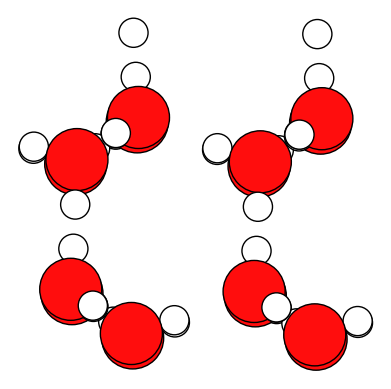

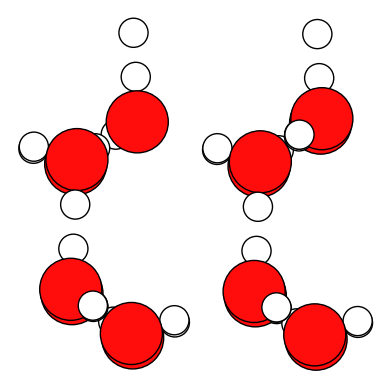

In [22]:
undistr_energy = scf_results['scf_all'][0][1]['scf_energy']
disturbed_energy = defect_scf_results['scf_all'][0][1]['scf_energy']
chemi_pot = chem_pot_scf_results['scf_all'][0][1]['scf_energy']

print(f'Energies: \n \t No Defect Lattice: {undistr_energy} \n \t Defect Lattice: {disturbed_energy}\n \t Diff: {disturbed_energy-undistr_energy+chemi_pot} Hartree or \n \t {(disturbed_energy-undistr_energy+chemi_pot)*27} eV/mol')

plot_atoms(read(PDB_FILE))
plot_atoms(read(DEFECT_PDB_FILE))

## Testing Point Defect in Ice 1h using SCF_driver (Draft)

In [ ]:
from veloxchem import scfdriver



## Testing Point Defects in NaCl (ionic and pair defects)

In [21]:
from ase.build import bulk
from ase.spacegroup import crystal
from ase.build import find_optimal_cell_shape
from ase.build import make_supercell
from ase.visualize.plot import plot_atoms
from ase.io import read, write

9.555652811707567
11.00347899529962
10.424348521862804
0.8686957101552366
11.293044232018037
1.737391420310471
10.134783285144392
0.5791304734368271
11.003478995299625
1.447826183592056
10.71391375858121
1.158260946873645
8.397391864833924
9.845218048425982
9.26608757498916
10.713913758581212
10.134783285144392
11.582609468736448
7.239130917960277
8.686957101552332
8.107826628115511
9.55565281170757
8.976522338270746
10.424348521862804
9.845218048425979
11.293044232018035
10.713913758581214
12.161739942173266
7.818261391397099
9.266087574989157
8.686957101552336
10.134783285144392
9.555652811707567
11.003478995299623
10.424348521862802
11.872174705454858
11.293044232018035
0.2895652367184107
8.39739186483392
9.845218048425979
9.266087574989157
10.713913758581212
10.134783285144392
11.582609468736447
11.003478995299627
1.447826183592056
11.872174705454853
0.8686957101552333
8.976522338270744
10.424348521862802
9.845218048425979
11.293044232018035
10.713913758581212
1.1582609468736444
11

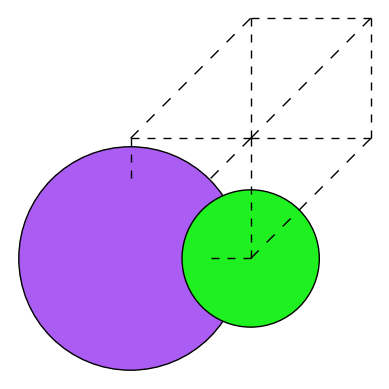

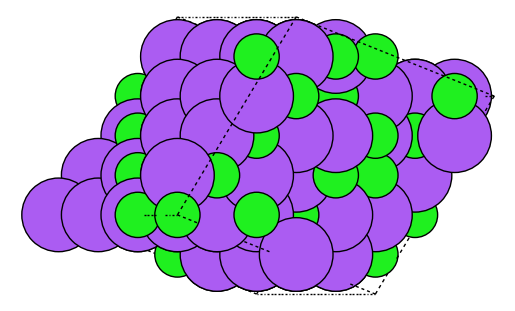

In [22]:
PATH = PATH
NACL_GENERAL_FILE_NAME = 'supercell_nacl'
# nacl = crystal(
#     symbols='NaCl', 
#     basis=[[0,0,0]],#, [0,1,0]],
#     spacegroup=227,
#     cellpar=[1,1,1, 90, 90, 90],
#     size=(2,2,2)
#     )

nacl = bulk('NaCl', 'rocksalt', a=3.57)

plot_atoms(nacl)

P = find_optimal_cell_shape(
    cell = nacl.cell,
    target_shape='sc',
    target_size=100
    )

supercell_nacl = make_supercell(nacl, P)

plot_atoms(supercell_nacl)

write(filename=f'{PATH}/{NACL_GENERAL_FILE_NAME}.cif', images=supercell_nacl, format='cif')

candidate_qm_nacl = get_centeroid_region(f'{PATH}/{NACL_GENERAL_FILE_NAME}.cif', cuboid_threshold=0.1, target_atom_symbol=['Na', 'Cl'], residue_len=2)


In [38]:
# Writes supercell to a file
write(filename=f'{PATH}/{NACL_GENERAL_FILE_NAME}.pdb', images=supercell_nacl)

# Processes that file
process_pdb(
    filename=f'{PATH}/{NACL_GENERAL_FILE_NAME}.pdb',
    atoms_per_mol=1,
    target_filename=f'{PATH}/{NACL_GENERAL_FILE_NAME}.pdb',
    qm_resname='LIG',
    qm_indecies=candidate_qm_nacl,
    global_resname=None,
    atom_type_resnames={'NA':'NA', 'CL':'CL'}
)

# Calculate qm_charge and multiplicity
supercell_nacl = read(f'{PATH}/{NACL_GENERAL_FILE_NAME}.cif')
np_supercell = np.array(supercell_nacl)

n = sum(1 for idx in candidate_qm_nacl if np_supercell[idx].symbol == 'Na')
m = sum(1 for idx in candidate_qm_nacl if np_supercell[idx].symbol == 'Cl')
qm_charge = n - m

# Calculates supercell energy from the file
nacl_scf_results = calc_energy(
    filename=f'{PATH}/{GENERAL_FILE_NAME}.pdb',
    qm_resname='LIG',
    qm_charge=qm_charge,           # net charge of the QM region
    qm_multiplicity=1,           # should be fine if total electrons are even
    pe_cutoff=0.6,
    npe_cutoff=None
)

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Hartree-Fock                                         
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

Del an ion

In [35]:
# Define defect supercell file name
DEFECT_NACL_GENERAL_FILE_NAME = f'defect_{NACL_GENERAL_FILE_NAME}'

# Copy the undisturbed supercell
defect_nacl = read(f'{PATH}/{NACL_GENERAL_FILE_NAME}.pdb')

# Delete one atom
del defect_nacl[77]

# Write the dsiturbed supercell to a new file:
write(f'{PATH}/{DEFECT_NACL_GENERAL_FILE_NAME}.cif', images=defect_nacl)
write(f'{PATH}/{DEFECT_NACL_GENERAL_FILE_NAME}.pdb', images=defect_nacl)

# Identify new qm_candidates (might be a logical bug here)
candidate_qm_defect_nacl = get_centeroid_region(f'{PATH}/{DEFECT_NACL_GENERAL_FILE_NAME}.cif', cuboid_threshold=0.1, target_atom_symbol=['Na', 'Cl'], residue_len=2)


# Process that pdb file. 
# write(filename=f'{PATH}/{DEFECT_NACL_GENERAL_FILE_NAME}.pdb', images=supercell_nacl)
process_pdb(
    filename=f'{PATH}/{DEFECT_NACL_GENERAL_FILE_NAME}.pdb',
    atoms_per_mol=1,
    target_filename=f'{PATH}/{DEFECT_NACL_GENERAL_FILE_NAME}.pdb',
    qm_resname='LIG',
    qm_indecies=candidate_qm_defect_nacl,
    global_resname=None,
    atom_type_resnames={'NA':'NA', 'CL':'CL'}
)

# Calculate qm charge and multiplicity:
#_nacl = read(f'{PATH}/{DEFECT_NACL_GENERAL_FILE_NAME}.pdb')
np_defect_nacl = np.array(defect_nacl)

n = sum(1 for idx in candidate_qm_defect_nacl if np_defect_nacl[idx].symbol == 'Na')
m = sum(1 for idx in candidate_qm_defect_nacl if np_defect_nacl[idx].symbol == 'Cl')
qm_charge = n - m



9.556
11.003
10.424
0.869
11.293
1.737
10.135
0.579
11.003
1.448
10.714
1.158
8.397
9.845
9.266
10.714
10.135
11.583
7.239
8.687
8.108
9.556
8.977
10.424
9.845
11.293
10.714
12.162
7.818
9.266
8.687
10.135
9.556
11.003
10.424
11.872
11.293
0.29
8.397
9.845
9.266
10.714
10.135
11.583
11.003
1.448
11.872
0.869
8.977
10.424
9.845
11.293
10.714
1.158
11.583
2.027
5.212
6.66
6.081
7.529
6.95
8.397
7.818
9.266
5.791
7.239
6.66
8.108
7.529
8.977
8.397
9.845
5.502
6.95
6.37
7.818
7.239
8.108
9.556
8.977
10.424
6.081
7.529
6.95
8.397
7.818
9.266
8.687
10.135
9.556
11.003
6.66
8.108
7.529
8.977
4.923
6.37
5.791
5.791
2.896
4.343
3.764
5.212
4.633
6.081
5.502
6.95
6.37
6.37
3.475
4.923
4.343
5.791
5.212
6.66
6.081
7.529
4.054
5.502
4.923
6.37
5.791
7.239
6.66
8.108
4.633
6.081
5.502
6.95
6.37
7.818
7.239
8.687
0.0
1.448
0.869
2.317
1.737
3.185
2.606
4.054
3.475
4.923
0.579
2.027
1.448
2.896
2.317
3.764
3.185
4.633
4.054
5.502
1.158
2.606
2.027
3.475
2.896
4.343
3.764
5.212
4.633
6.081
1.737
3.185

In [36]:
defect_nacl_scf_results = calc_energy(
    filename=f'{PATH}/{DEFECT_NACL_GENERAL_FILE_NAME}.pdb',
    qm_resname='LIG',
    qm_charge=qm_charge,           # net charge of the QM region
    qm_multiplicity=1,           # should be fine if total electrons are even
    pe_cutoff=0.6,
    npe_cutoff=None
)

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Hartree-Fock                                         
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

In [41]:
# Define defect supercell file name
PAIR_DEFECT_NACL_FILE_NAME = f'defect_{NACL_GENERAL_FILE_NAME}'

# Copy the undisturbed supercell
pair_defect_nacl = read(f'{PATH}/{NACL_GENERAL_FILE_NAME}.pdb')

# Delete one atom
del pair_defect_nacl[76:77]

# Write the dsiturbed supercell to a new file:
write(f'{PATH}/{PAIR_DEFECT_NACL_FILE_NAME}.cif', images=pair_defect_nacl)
write(f'{PATH}/{PAIR_DEFECT_NACL_FILE_NAME}.pdb', images=pair_defect_nacl)

# Identify new qm_candidates (might be a logical bug here)
candidate_qm_pair_defect_nacl = get_centeroid_region(f'{PATH}/{PAIR_DEFECT_NACL_FILE_NAME}.cif', cuboid_threshold=0.1, target_atom_symbol=['Na', 'Cl'], residue_len=2)


# Process that pdb file. 
# write(filename=f'{PATH}/{DEFECT_NACL_GENERAL_FILE_NAME}.pdb', images=supercell_nacl)
process_pdb(
    filename=f'{PATH}/{PAIR_DEFECT_NACL_FILE_NAME}.pdb',
    atoms_per_mol=1,
    target_filename=f'{PATH}/{PAIR_DEFECT_NACL_FILE_NAME}.pdb',
    qm_resname='LIG',
    qm_indecies=candidate_qm_pair_defect_nacl,
    global_resname=None,
    atom_type_resnames={'NA':'NA', 'CL':'CL'}
)

# Calculate qm charge and multiplicity:
#_nacl = read(f'{PATH}/{DEFECT_NACL_GENERAL_FILE_NAME}.pdb')
np_pair_defect_nacl = np.array(pair_defect_nacl)

n = sum(1 for idx in candidate_qm_pair_defect_nacl if np_pair_defect_nacl[idx].symbol == 'Na')
m = sum(1 for idx in candidate_qm_pair_defect_nacl if np_pair_defect_nacl[idx].symbol == 'Cl')
qm_charge = n - m

pair_defect_nacl_scf_results = calc_energy(
    filename=f'{PATH}/{PAIR_DEFECT_NACL_FILE_NAME}.pdb',
    qm_resname='LIG',
    qm_charge=qm_charge,           # net charge of the QM region
    qm_multiplicity=1,           # should be fine if total electrons are even
    pe_cutoff=0.6,
    npe_cutoff=None
)



9.556
11.003
10.424
0.869
11.293
1.737
10.135
0.579
11.003
1.448
10.714
1.158
8.397
9.845
9.266
10.714
10.135
11.583
7.239
8.687
8.108
9.556
8.977
10.424
9.845
11.293
10.714
12.162
7.818
9.266
8.687
10.135
9.556
11.003
10.424
11.872
11.293
0.29
8.397
9.845
9.266
10.714
10.135
11.583
11.003
1.448
11.872
0.869
8.977
10.424
9.845
11.293
10.714
1.158
11.583
2.027
5.212
6.66
6.081
7.529
6.95
8.397
7.818
9.266
5.791
7.239
6.66
8.108
7.529
8.977
8.397
9.845
5.502
6.95
6.37
7.818
8.687
8.108
9.556
8.977
10.424
6.081
7.529
6.95
8.397
7.818
9.266
8.687
10.135
9.556
11.003
6.66
8.108
7.529
8.977
4.923
6.37
5.791
5.791
2.896
4.343
3.764
5.212
4.633
6.081
5.502
6.95
6.37
6.37
3.475
4.923
4.343
5.791
5.212
6.66
6.081
7.529
4.054
5.502
4.923
6.37
5.791
7.239
6.66
8.108
4.633
6.081
5.502
6.95
6.37
7.818
7.239
8.687
0.0
1.448
0.869
2.317
1.737
3.185
2.606
4.054
3.475
4.923
0.579
2.027
1.448
2.896
2.317
3.764
3.185
4.633
4.054
5.502
1.158
2.606
2.027
3.475
2.896
4.343
3.764
5.212
4.633
6.081
1.737
3.185

/opt/anaconda3/envs/vlxenv/lib/python3.13/site-packages/MDAnalysis/core/universe.py:607: DeprecationWarning: Bond guessing through the `guess_bonds` keyword is deprecated and will be removed in MDAnalysis 3.0. Instead, pass 'bonds', 'angles', and 'dihedrals' to the `to_guess` keyword in Universe for guessing these if they are not present, or `force_guess` if they are and you wish to replace these bonds with guessed values. The kwargs `fudge_factor`, `vdwradii`, and `lower_bound` are also deprecated and will be removed in MDAnalysis 3.0, where they should be passed into the Context for guessing on Universe instantiation. If using guess_TopologyAttrs, pass these kwargs to the method instead, as they will override the previous Context values.
  warnings.warn(


                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Hartree-Fock                                         
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

Energies: 
 	 No Defect Lattice: -227.96734759702042 
 	 Defect Lattice: -944.2525002571972
 	 Pair Defect Lattice: -621.272890754434 
 
 	 Diff (ionic point defect): -716.2851526601768 Hartree or -19339.69912182477 eV/mol 
 	 Diff (Pair defect): -393.3055431574136 Hartree  or -10619.249665250167 eV/mol


<Axes: >

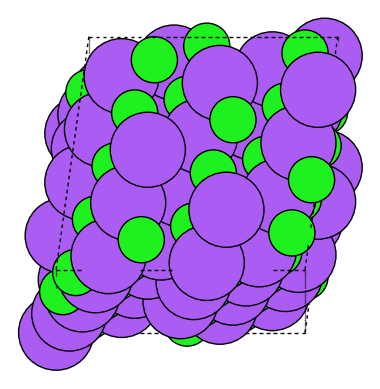

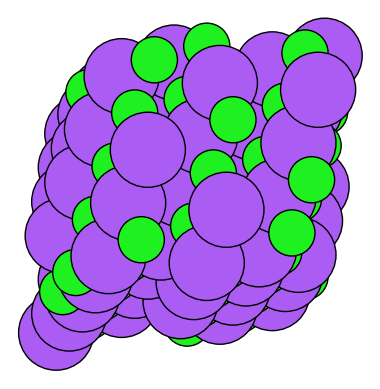

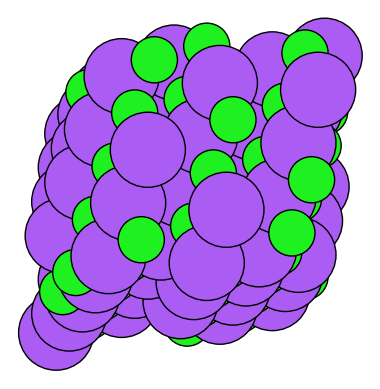

In [44]:
undistr_energy = nacl_scf_results['scf_all'][0][1]['scf_energy']
disturbed_energy = defect_nacl_scf_results['scf_all'][0][1]['scf_energy']
pair_defect_energy = pair_defect_nacl_scf_results['scf_all'][0][1]['scf_energy']

print(f'Energies: \n \t No Defect Lattice: {undistr_energy} \n \t Defect Lattice: {disturbed_energy}\n \t Pair Defect Lattice: {pair_defect_energy} \n \n \t Diff (ionic point defect): {disturbed_energy-undistr_energy} Hartree or {(disturbed_energy-undistr_energy)*27} eV/mol \n \t Diff (Pair defect): {(pair_defect_energy-undistr_energy)} Hartree  or {(pair_defect_energy-undistr_energy)*27} eV/mol')
plot_atoms(supercell_nacl)
plot_atoms(defect_nacl)
plot_atoms(pair_defect_nacl)

## Defects in Benzene (Draft)

/opt/anaconda3/envs/vlxenv/lib/python3.13/site-packages/ase/io/cif.py:411: UserWarning: crystal system 'triclinic' is not interpreted for space group Spacegroup(2, setting=1). This may result in wrong setting!
  warnings.warn(


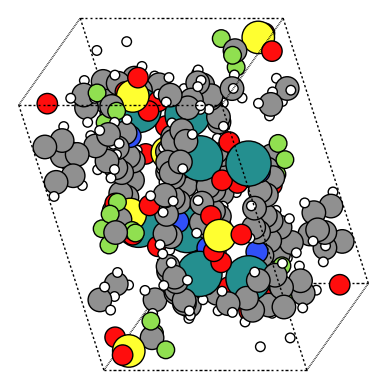

In [48]:
BENZENE_FILE_NAME = 'benzene'
benzene = read(f'{PATH}/{BENZENE_FILE_NAME}.cif')
plot_atoms(benzene)

write(
    filename=f'{PATH}/{BENZENE_FILE_NAME}.pdb',
    images=benzene
    )

In [ ]:
# PROCESS PDB FILE MANUALLY PLEASE
#  process_pdb(
#     filename=f'{PATH}/{BENZENE_FILE_NAME}.pdb',
#     atoms_per_mol=
# )